In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PRICES_PATH = Path("/Users/tradingworkspace/TradingWorkspace/data-engineering/Market Data/Cleaned/etf_prices_master.parquet")
TARGETS_PATH = Path("/Users/tradingworkspace/TradingWorkspace/data-engineering/notebooks/Market Data/Cleaned/etf_targets_monthly.parquet")
OUTPUT_DIR = Path("/Users/tradingworkspace/TradingWorkspace/data-engineering/notebooks/Market Data/Cleaned")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
prices = pd.read_parquet(PRICES_PATH)
targets = pd.read_parquet(TARGETS_PATH)

prices["date"] = pd.to_datetime(prices["date"])
targets["date"] = pd.to_datetime(targets["date"])

prices = prices.sort_values(["symbol", "date"]).reset_index(drop=True)
targets = targets.sort_values(["date", "symbol"]).reset_index(drop=True)

print(prices.shape)
print(targets.shape)

prices.head(), targets.head()

(103131, 9)
(4643, 7)


(        date symbol   open   high    low  close   volume    nav  \
 0 2007-06-01    BIL  91.62  91.62  91.62  91.62   1450.0  91.56   
 1 2007-06-04    BIL  91.64  91.64  91.64  91.64   1050.0  91.60   
 2 2007-06-05    BIL  91.66  91.68  91.64  91.64   3750.0  91.61   
 3 2007-06-06    BIL  91.64  91.68  91.64  91.68   9750.0  91.63   
 4 2007-06-07    BIL  91.64  91.66  91.64  91.66  12150.0  91.64   
 
    total_return_gross  
 0               91.62  
 1               91.64  
 2               91.64  
 3               91.68  
 4               91.66  ,
         date symbol   bucket  close    volume  target_weight  signal
 0 1993-02-26    SPY  core_us  44.41   66200.0            0.6    True
 1 1993-03-31    SPY  core_us  45.19  111600.0            0.6    True
 2 1993-04-30    SPY  core_us  44.03   88500.0            0.6    True
 3 1993-05-28    SPY  core_us  45.22   79100.0            0.6    True
 4 1993-06-30    SPY  core_us  45.06  437600.0            0.6    True)

In [3]:
prices["daily_return"] = prices.groupby("symbol")["close"].pct_change()

returns_wide = prices.pivot(index="date", columns="symbol", values="daily_return").sort_index()
close_wide = prices.pivot(index="date", columns="symbol", values="close").sort_index()

returns_wide.tail()

symbol,BIL,ETHA,GLD,IBIT,IEI,INDA,QQQ,SHY,SLV,SPY,...,UNG,USO,VEA,VFH,VHT,VIS,VIXY,VNQ,VPU,VWO
date,,,,,,,,,,,,,,,,,,,,,
2026-03-02,-0.002510,0.058540,0.012920,0.054047,-0.006958,-0.025253,0.001317,-0.004448,-0.040240,0.000569,...,0.041667,0.063941,-0.017511,0.000876,-0.009543,0.009390,0.012922,0.002508,-0.006800,-0.014802
2026-03-03,0.000109,-0.028627,-0.044612,-0.012755,-0.000501,-0.014328,-0.010706,-0.000121,-0.084467,-0.008814,...,0.023333,0.034522,-0.034778,-0.001989,-0.011104,-0.020634,0.046421,-0.005316,-0.006113,-0.035115
2026-03-04,0.000109,0.088413,0.007818,0.070801,-0.001836,0.000996,0.015243,-0.000604,0.008838,0.007055,...,-0.040717,0.015078,0.011560,0.004943,0.002764,0.004143,-0.033864,0.001258,0.004478,0.006337
2026-03-05,0.000109,-0.027692,-0.012018,-0.025338,-0.001672,0.001989,-0.003013,-0.000725,-0.014202,-0.005576,...,0.022920,0.051879,-0.023598,-0.006665,-0.019536,-0.022721,0.063792,-0.010048,-0.008083,-0.013134
2026-03-06,0.000219,-0.055063,0.015832,-0.044318,0.000084,-0.007544,-0.015043,0.000484,0.022486,-0.013107,...,0.058091,0.129374,-0.007752,-0.014137,-0.008504,-0.016193,0.135091,-0.010890,-0.004346,-0.006928


In [4]:
weights_wide = (
    targets.pivot(index="date", columns="symbol", values="target_weight")
    .sort_index()
    .fillna(0.0)
)

weights_wide.tail()

symbol,BIL,GLD,IEI,INDA,QQQ,SHY,SLV,SPY,TLT,UNG,USO,VEA,VFH,VHT,VIS,VNQ,VPU,VWO
date,,,,,,,,,,,,,,,,,,
2025-11-28,0.0125,0.01,0.0125,0.033333,0.3,0.0125,0.01,0.3,0.0125,0.01,0.01,0.033333,0.05,0.05,0.05,0.01,0.05,0.033333
2025-12-31,0.0125,0.01,0.0125,0.033333,0.3,0.0125,0.01,0.3,0.0125,0.01,0.01,0.033333,0.05,0.05,0.05,0.01,0.05,0.033333
2026-01-30,0.0125,0.01,0.0125,0.033333,0.3,0.0125,0.01,0.3,0.0125,0.01,0.01,0.033333,0.05,0.05,0.05,0.01,0.05,0.033333
2026-02-27,0.0125,0.01,0.0125,0.033333,0.3,0.0125,0.01,0.3,0.0125,0.01,0.01,0.033333,0.05,0.05,0.05,0.01,0.05,0.033333
2026-03-06,0.0125,0.01,0.0125,0.033333,0.3,0.0125,0.01,0.3,0.0125,0.01,0.01,0.033333,0.05,0.05,0.05,0.01,0.05,0.033333


In [5]:
daily_weights = weights_wide.reindex(returns_wide.index).ffill().fillna(0.0)

daily_weights.tail()

symbol,BIL,GLD,IEI,INDA,QQQ,SHY,SLV,SPY,TLT,UNG,USO,VEA,VFH,VHT,VIS,VNQ,VPU,VWO
date,,,,,,,,,,,,,,,,,,
2026-03-02,0.0125,0.01,0.0125,0.033333,0.3,0.0125,0.01,0.3,0.0125,0.01,0.01,0.033333,0.05,0.05,0.05,0.01,0.05,0.033333
2026-03-03,0.0125,0.01,0.0125,0.033333,0.3,0.0125,0.01,0.3,0.0125,0.01,0.01,0.033333,0.05,0.05,0.05,0.01,0.05,0.033333
2026-03-04,0.0125,0.01,0.0125,0.033333,0.3,0.0125,0.01,0.3,0.0125,0.01,0.01,0.033333,0.05,0.05,0.05,0.01,0.05,0.033333
2026-03-05,0.0125,0.01,0.0125,0.033333,0.3,0.0125,0.01,0.3,0.0125,0.01,0.01,0.033333,0.05,0.05,0.05,0.01,0.05,0.033333
2026-03-06,0.0125,0.01,0.0125,0.033333,0.3,0.0125,0.01,0.3,0.0125,0.01,0.01,0.033333,0.05,0.05,0.05,0.01,0.05,0.033333


In [6]:
daily_weights = daily_weights.shift(1).fillna(0.0)

daily_weights.tail()

symbol,BIL,GLD,IEI,INDA,QQQ,SHY,SLV,SPY,TLT,UNG,USO,VEA,VFH,VHT,VIS,VNQ,VPU,VWO
date,,,,,,,,,,,,,,,,,,
2026-03-02,0.0125,0.01,0.0125,0.033333,0.3,0.0125,0.01,0.3,0.0125,0.01,0.01,0.033333,0.05,0.05,0.05,0.01,0.05,0.033333
2026-03-03,0.0125,0.01,0.0125,0.033333,0.3,0.0125,0.01,0.3,0.0125,0.01,0.01,0.033333,0.05,0.05,0.05,0.01,0.05,0.033333
2026-03-04,0.0125,0.01,0.0125,0.033333,0.3,0.0125,0.01,0.3,0.0125,0.01,0.01,0.033333,0.05,0.05,0.05,0.01,0.05,0.033333
2026-03-05,0.0125,0.01,0.0125,0.033333,0.3,0.0125,0.01,0.3,0.0125,0.01,0.01,0.033333,0.05,0.05,0.05,0.01,0.05,0.033333
2026-03-06,0.0125,0.01,0.0125,0.033333,0.3,0.0125,0.01,0.3,0.0125,0.01,0.01,0.033333,0.05,0.05,0.05,0.01,0.05,0.033333


In [7]:
common_cols = sorted(set(daily_weights.columns).intersection(set(returns_wide.columns)))

daily_weights = daily_weights[common_cols]
returns_wide = returns_wide[common_cols]

portfolio_daily_return = (daily_weights * returns_wide).sum(axis=1)
portfolio_daily_return = portfolio_daily_return.fillna(0.0)

portfolio_daily_return.head()

date
1993-02-01    0.0
1993-02-02    0.0
1993-02-03    0.0
1993-02-04    0.0
1993-02-05    0.0
dtype: float64

In [8]:
initial_capital = 1_000_000

equity_curve = initial_capital * (1 + portfolio_daily_return).cumprod()

backtest = pd.DataFrame({
    "portfolio_return": portfolio_daily_return,
    "equity": equity_curve,
}, index=portfolio_daily_return.index)

backtest.head()

,portfolio_return,equity
date,,
1993-02-01,0.0,1000000.0
1993-02-02,0.0,1000000.0
1993-02-03,0.0,1000000.0
1993-02-04,0.0,1000000.0
1993-02-05,0.0,1000000.0


In [9]:
def compute_cagr(equity: pd.Series) -> float:
    n_days = (equity.index.max() - equity.index.min()).days
    if n_days <= 0:
        return np.nan
    years = n_days / 365.25
    return (equity.iloc[-1] / equity.iloc[0]) ** (1 / years) - 1

def compute_max_drawdown(equity: pd.Series) -> float:
    running_max = equity.cummax()
    drawdown = equity / running_max - 1
    return drawdown.min()

def compute_sharpe(daily_returns: pd.Series, rf=0.0) -> float:
    excess = daily_returns - rf / 252
    vol = excess.std()
    if vol == 0 or pd.isna(vol):
        return np.nan
    return np.sqrt(252) * excess.mean() / vol

cagr = compute_cagr(backtest["equity"])
ann_vol = backtest["portfolio_return"].std() * np.sqrt(252)
sharpe = compute_sharpe(backtest["portfolio_return"])
max_dd = compute_max_drawdown(backtest["equity"])
total_return = backtest["equity"].iloc[-1] / backtest["equity"].iloc[0] - 1

stats = pd.Series({
    "Total Return": total_return,
    "CAGR": cagr,
    "Annual Volatility": ann_vol,
    "Sharpe": sharpe,
    "Max Drawdown": max_dd,
})

stats

Total Return         11.621052
CAGR                  0.079633
Annual Volatility     0.164706
Sharpe                0.548093
Max Drawdown         -0.529881
dtype: float64

In [10]:
annual_returns = (
    backtest["portfolio_return"]
    .groupby(backtest.index.year)
    .apply(lambda x: (1 + x).prod() - 1)
)

annual_returns

date
1993    0.030014
1994   -0.011981
1995    0.198102
1996    0.118490
1997    0.184097
1998    0.161368
1999    0.270542
2000   -0.128590
2001   -0.127427
2002   -0.180227
2003    0.216544
2004    0.077368
2005    0.061660
2006    0.124174
2007    0.109362
2008   -0.370445
2009    0.321898
2010    0.158673
2011   -0.007678
2012    0.133954
2013    0.241516
2014    0.116661
2015   -0.003821
2016    0.082062
2017    0.212295
2018   -0.048753
2019    0.269451
2020    0.207118
2021    0.224092
2022   -0.194344
2023    0.237424
2024    0.187203
2025    0.174889
2026    0.004010
Name: portfolio_return, dtype: float64

In [11]:
monthly_returns = (
    backtest["portfolio_return"]
    .groupby(backtest.index.to_period("M"))
    .apply(lambda x: (1 + x).prod() - 1)
    .to_timestamp()
)

monthly_returns.tail(24)

date
2024-04-01   -0.032860
2024-05-01    0.049254
2024-06-01    0.026523
2024-07-01    0.011868
2024-08-01    0.020183
2024-09-01    0.022226
2024-10-01   -0.013992
2024-11-01    0.047003
2024-12-01   -0.027632
2025-01-01    0.028107
2025-02-01   -0.009277
2025-03-01   -0.042445
2025-04-01   -0.001786
2025-05-01    0.055763
2025-06-01    0.043539
2025-07-01    0.014778
2025-08-01    0.016125
2025-09-01    0.034565
2025-10-01    0.027184
2025-11-01    0.005381
2025-12-01   -0.005765
2026-01-01    0.022879
2026-02-01    0.001706
2026-03-01   -0.020119
Freq: MS, Name: portfolio_return, dtype: float64

In [12]:
running_max = backtest["equity"].cummax()
drawdown = backtest["equity"] / running_max - 1

backtest["drawdown"] = drawdown
backtest.tail()

,portfolio_return,equity,drawdown
date,,,
2026-03-02,-0.001190,1.286487e+07,-0.008623
2026-03-03,-0.011452,1.271753e+07,-0.019977
2026-03-04,0.007990,1.281915e+07,-0.012146
2026-03-05,-0.006279,1.273866e+07,-0.018348
2026-03-06,-0.009233,1.262105e+07,-0.027411


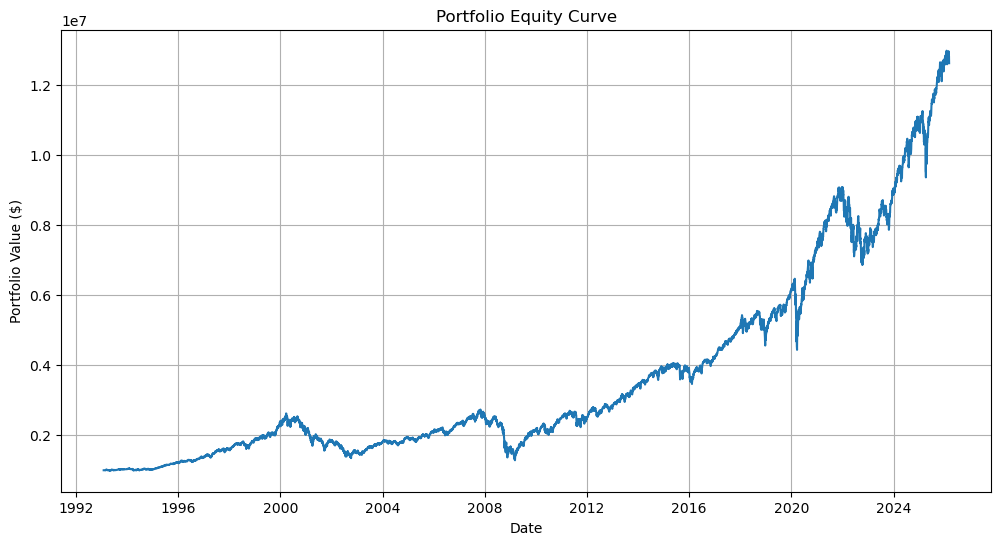

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(backtest.index, backtest["equity"])
plt.title("Portfolio Equity Curve")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.grid(True)
plt.show()

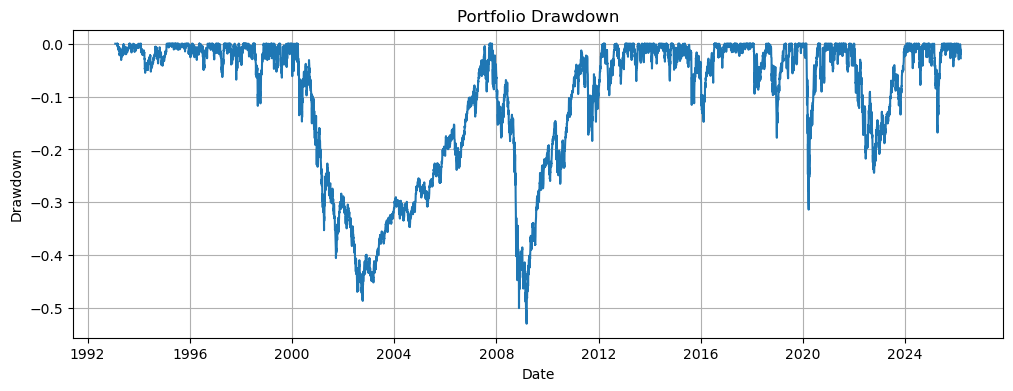

In [14]:
plt.figure(figsize=(12, 4))
plt.plot(backtest.index, backtest["drawdown"])
plt.title("Portfolio Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True)
plt.show()